# Class-conditional Evidence Set Network — seed 42 screen

목적: fold-train Empirical-Bayes event evidence를 후보 암종별 event set으로 유지하는 listwise network를 검증합니다.

- 데이터는 train만 읽습니다.
- event vocabulary·support·EB weight·standardization은 fit partition에서만 생성합니다.
- team baseline을 재학습하지 않습니다. row-aligned train-only team OOF CSV를 제공할 때만 paired 비교합니다.
- `BASELINE_OOF=None`이면 공개 team 기준점 `0.54202`와 unpaired screen만 수행하며 3-seed 승격은 차단합니다.
- seed 42 screen 통과 기준: +0.030, 4/5 fold 상승, 저마진 +0.040, 15개 이상 클래스 개선.


In [4]:
from pathlib import Path
import subprocess, sys
from tqdm.auto import tqdm

ROOT = next(path for path in (Path.cwd(), *Path.cwd().parents) if (path / 'experiments/gs/notebooks/exp_model_005/common/run_evidence_set_network.py').exists())
RUNNER = ROOT / 'experiments/gs/notebooks/exp_model_005/common/run_evidence_set_network.py'
RESULT = RUNNER.parent.parent / 'result'
RUN_ID = 'exp-class-conditional-evidence-set-network-01'
SEED = 42
RUN_EXPERIMENT = True
BASELINE_OOF = None  # Optional: row-aligned, train-only team OOF probability CSV

{'runner': RUNNER, 'result_dir': RESULT, 'seed': SEED, 'train_only_contract': True}


{'runner': PosixPath('/Users/admin/Documents/FinalProject/OZ_fianl_hackaton/experiments/gs/notebooks/exp_model_005/common/run_evidence_set_network.py'),
 'result_dir': PosixPath('/Users/admin/Documents/FinalProject/OZ_fianl_hackaton/experiments/gs/notebooks/exp_model_005/result'),
 'seed': 42,
 'train_only_contract': True}

In [5]:
if RUN_EXPERIMENT:
    command = [sys.executable, str(RUNNER), '--seed', str(SEED), '--run-id', RUN_ID]
    if BASELINE_OOF is not None:
        command += ['--baseline-oof', str(BASELINE_OOF)]
    process = subprocess.Popen(command, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1)
    tail = []
    for line in tqdm(process.stdout, desc='evidence-set runner', unit='line'):
        print(line, end='')
        tail = (tail + [line])[-120:]
    if process.wait():
        raise RuntimeError('Evidence Set runner failed:\n' + ''.join(tail))
else:
    print('RUN_EXPERIMENT=False: 결과 파일만 읽습니다.')


evidence-set runner: 0line [00:00, ?line/s]

evidence-set runner: 1line [00:05,  5.90s/line]

[stage] baseline comparison: unpaired_reference
[stage] train-only mutation parsing


evidence-set runner: 3line [00:18,  6.27s/line]

[stage] outer fold 1/5: inner OOF evidence


...

evidence-set runner: 6line [2:13:02, 1859.23s/line]

[stage] outer fold 4/5: inner OOF evidence


evidence-set runner: 7line [3:03:41, 2230.12s/line]

[stage] outer fold 5/5: inner OOF evidence


evidence-set runner: 7line [3:49:56, 1970.91s/line]


In [6]:
import json
import matplotlib.pyplot as plt
import pandas as pd

summary = pd.read_csv(RESULT / f'{RUN_ID}_seed{SEED}_summary.csv')
folds = pd.read_csv(RESULT / f'{RUN_ID}_seed{SEED}_fold_metrics.csv')
classes = pd.read_csv(RESULT / f'{RUN_ID}_seed{SEED}_class_metrics.csv')
low_margin = pd.read_csv(RESULT / f'{RUN_ID}_seed{SEED}_low_margin_metrics.csv')
audit = pd.read_csv(RESULT / f'{RUN_ID}_seed{SEED}_nested_audit.csv')
contract = json.loads((RESULT / f'{RUN_ID}_seed{SEED}_feature_contract.json').read_text())
leakage = json.loads((RESULT / f'{RUN_ID}_seed{SEED}_leakage_audit.json').read_text())

assert summary.leakage_check.all() and summary.nan_as_mutation_count.eq(0).all()
assert audit.outer_validation_used_for_eb_fit.eq(False).all()
assert contract['train_only_vocabulary'] and not contract['test_read']
display(summary)
display(audit)
display(low_margin)
display(classes.sort_values('delta_network_vs_team') if 'delta_network_vs_team' in classes else classes)
leakage['promotion']


,variant,oof_macro_f1,feature_count,convergence_warning_count,leakage_check,nan_as_mutation_count,runtime_seconds,top1_recall,top2_recall,top3_recall,team_reference_macro_f1,delta_vs_team_3way,baseline_comparison_mode
0,evidence_set_network,0.297658,16,0,True,0,13792.556633,0.349299,0.466699,0.525883,0.54202,-0.244362,unpaired_reference


,seed,fold,ranker_training_rows_are_inner_oof,outer_validation_used_for_eb_fit,inner_oof_rows,outer_validation_rows,test_read
0,42,1,True,False,4960,1241,False
1,42,2,True,False,4961,1240,False
2,42,3,True,False,4961,1240,False
3,42,4,True,False,4961,1240,False
4,42,5,True,False,4961,1240,False


,variant,group,support,macro_f1
0,evidence_set_network,baseline_margin_<0.05,2505,0.097548


,class,evidence_set_network
0,ACC,0.301969
1,BLCA,0.241975
2,BRCA,0.479937
3,CESC,0.084906
4,COAD,0.592157
5,DLBC,0.246154
6,GBMLGG,0.334728
7,HNSC,0.282642
8,KIPAN,0.257511
9,KIRC,0.451400


{'delta_at_least_0_03': False,
 'paired_team_oof_supplied': False,
 'decision': 'reference_only_screen_requires_paired_team_oof'}

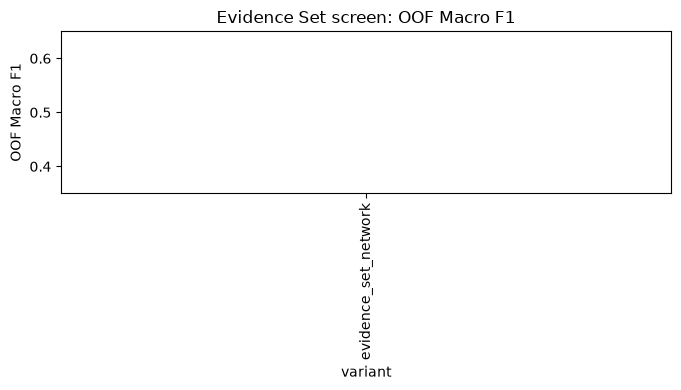

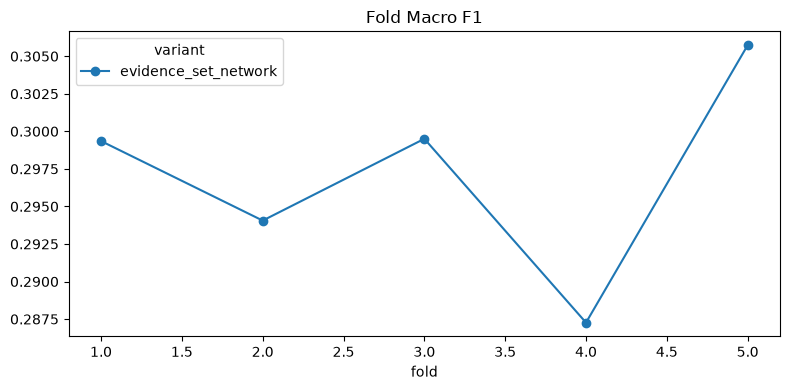

In [7]:
ax = summary.set_index('variant').oof_macro_f1.plot.bar(figsize=(7, 4), ylim=(0.35, 0.65), title='Evidence Set screen: OOF Macro F1')
ax.set_ylabel('OOF Macro F1')
plt.tight_layout(); plt.show()

folds.pivot(index='fold', columns='variant', values='macro_f1').plot(marker='o', figsize=(8, 4), title='Fold Macro F1')
plt.tight_layout(); plt.show()

if 'delta_network_vs_team' in classes:
    classes.sort_values('delta_network_vs_team').plot.barh(x='class', y='delta_network_vs_team', figsize=(7, 7), title='Class F1 delta: network − team')
    plt.axvline(0, color='black', linewidth=1); plt.tight_layout(); plt.show()
